In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import kagglehub
from imblearn.over_sampling import SMOTE
from rich.jupyter import display

#Download latest version
path = kagglehub.dataset_download("algozee/teenager-menthal-healy")
kagglehub.login()

print("Path to dataset files:", path)

Path to dataset files: /Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1


In [2]:
print("Arquivos no dataset:", os.listdir(path)) #verifica quais arquivos estão dentro da pasta

Arquivos no dataset: ['Teen_Mental_Health_Dataset.csv']


In [3]:
rota = os.path.join('/Users/danniells/.cache/kagglehub/datasets/algozee/teenager-menthal-healy/versions/1', 'Teen_Mental_Health_Dataset.csv') #junta o caminho da pasta com o arquivo

In [5]:
df = pd.read_csv(rota)
df.shape #linhas + colunas

(1200, 13)

In [7]:
df.head(8)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0


In [20]:
df['depression_label'].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

## EDA (Exploratory Data Analysis)

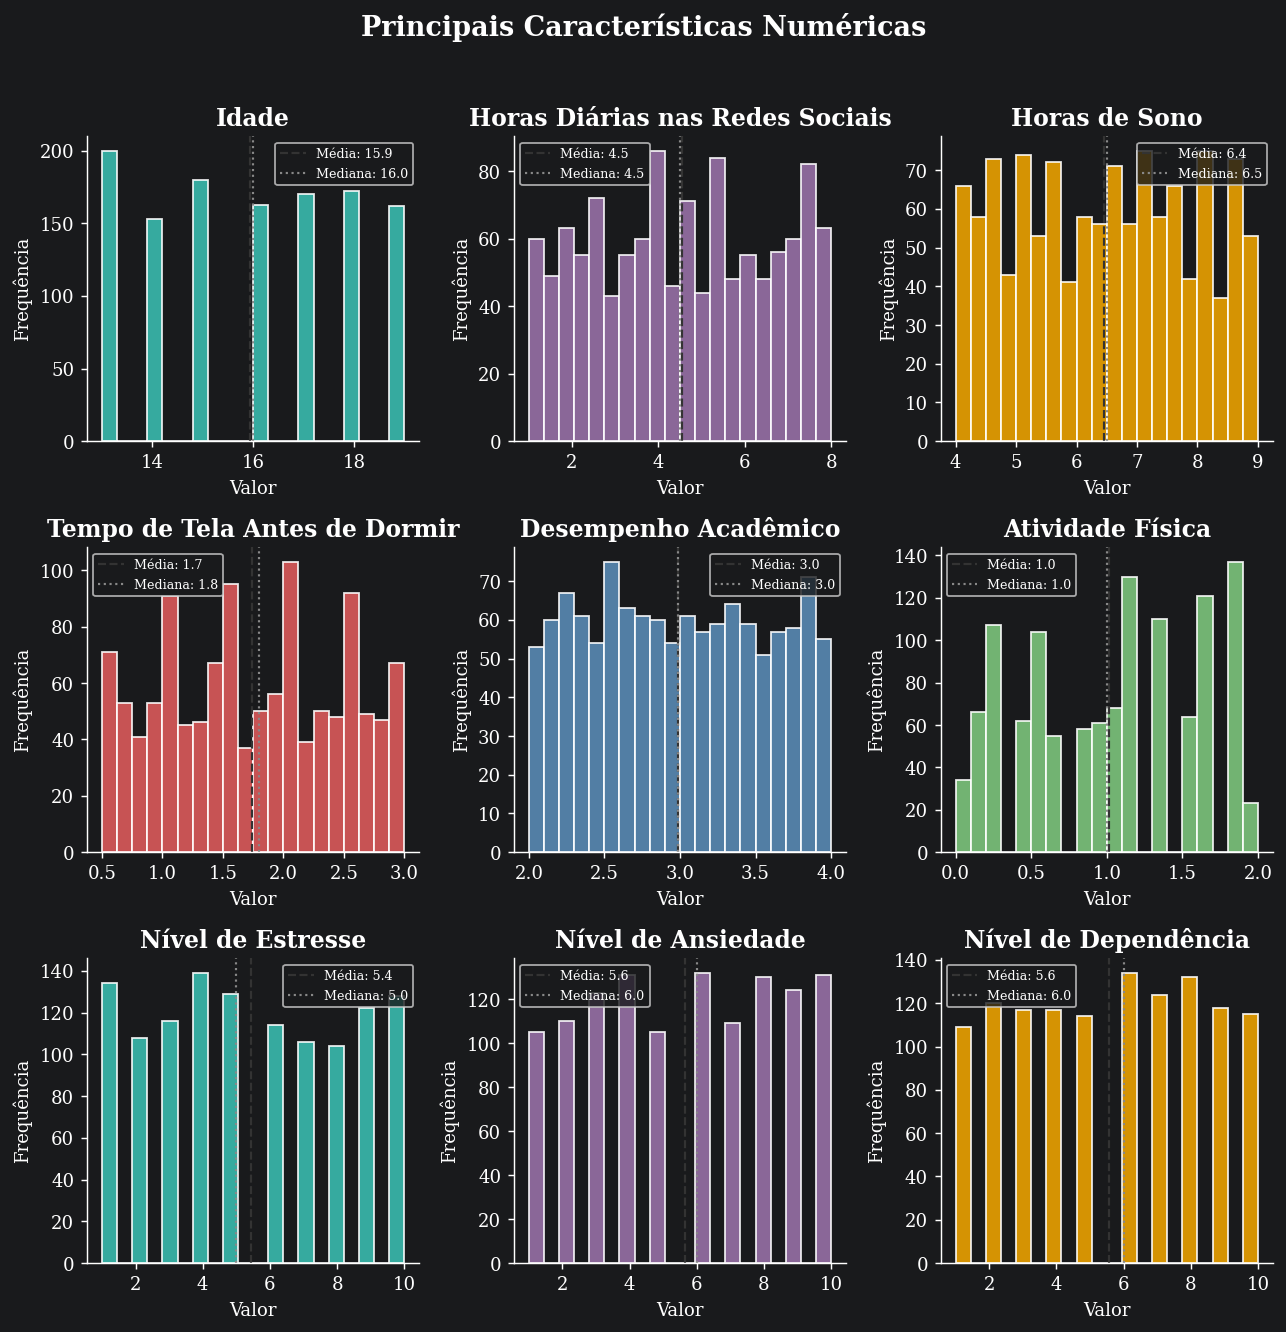

In [19]:
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore") #deixa a saída mais limpa, sem mostrar avisos de atualizações
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.dpi": 130, "font.family": "serif"
})

num_cols = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep",
            "academic_performance", "physical_activity", "stress_level", "anxiety_level", "addiction_level"]

titulos = {
    "age": "Idade",
    "daily_social_media_hours": "Horas Diárias nas Redes Sociais",
    "sleep_hours": "Horas de Sono",
    "screen_time_before_sleep": "Tempo de Tela Antes de Dormir",
    "academic_performance": "Desempenho Acadêmico",
    "physical_activity": "Atividade Física",
    "stress_level": "Nível de Estresse",
    "anxiety_level": "Nível de Ansiedade",
    "addiction_level": "Nível de Dependência"
}

colors = ["#3BBFB2", "#9B72AA", "#F0A500", "#E05C5C", "#5B8DB8", "#7FC97F"]

fig, axes = plt.subplots(3, 3, figsize=(10, 10)) #fig é a imagem inteira e axes é os 9 gráficos
fig.suptitle("Principais Características Numéricas", fontsize=15, fontweight="bold", y=1.02)

for i, ax in enumerate(axes.flatten()):
    col = num_cols[i]
    data = df[col].dropna() #joga valores nulos fora, caso haja
    ax.hist(data, bins=20, color=colors[i % len(colors)], edgecolor="white", alpha=0.88)

    ax.axvline(data.mean(), color="#333333", ls="--", lw=1.2, label=f"Média: {data.mean():.1f}")
    ax.axvline(data.median(), color="#888888", ls=":", lw=1.2, label=f"Mediana: {data.median():.1f}")

    ax.set(title=titulos[col], xlabel="Valor", ylabel="Frequência")
    ax.legend(fontsize=7)

plt.tight_layout() #arruma o espaçamento automaticamente
plt.savefig("chart1_distributions.png", bbox_inches="tight")
plt.show()

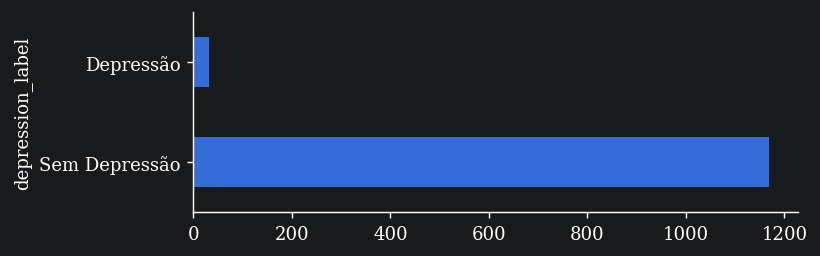

depression_label
0    1169
1      31
Name: count, dtype: int64


In [22]:
depressao = 'depression_label'
plt.figure(figsize=(6, 2))
df[depressao].value_counts().rename(index={1:'Depressão',0:'Sem Depressão'}).plot.barh()
plt.show()
print(df[depressao].value_counts())

In [23]:
print(df['social_interaction_level'].unique())
print(df['platform_usage'].unique())
print(df['gender'].unique())

['low' 'high' 'medium']
['Instagram' 'TikTok' 'Both']
['male' 'female']


In [24]:
#remove espaços e converte tudo para minusculo
df['gender'] = df['gender'].str.lower().str.strip()
df['platform_usage'] = df['platform_usage'].str.lower().str.strip()
df['social_interaction_level'] = df['social_interaction_level'].str.lower().str.strip()

#Converter os objetos em Int
df['gender'] = df['gender'].map({'male': 1, 'female': 0})
df['platform_usage'] = df['platform_usage'].map({'instagram': 0, 'tiktok': 1, 'both': 2})
df['social_interaction_level'] = df['social_interaction_level'].map({'low': 0, 'medium': 1, 'high': 2})

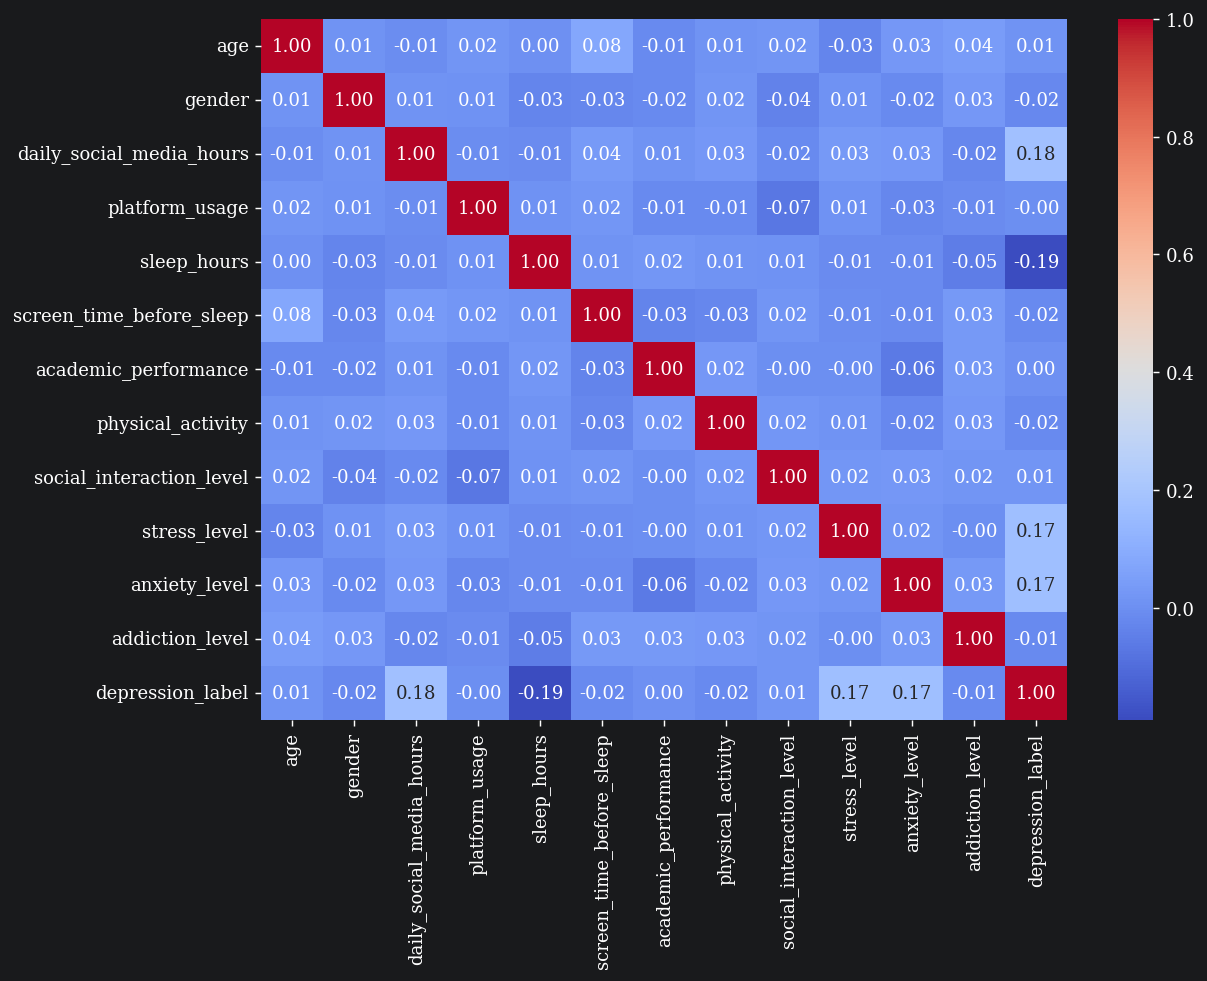

In [33]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [34]:
X = df.drop(depressao, axis=1)
y = df[depressao]

## Treino e Teste

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Tamanho do Treino: ', len(y_train))
print('Tamanho do Teste: ', len(y_test))
print('\nContagem de Testes:')
print(y_test.value_counts())

Tamanho do Treino:  960
Tamanho do Teste:  240

Contagem de Testes:
depression_label
0    234
1      6
Name: count, dtype: int64


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   int64  
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   int64  
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   int64  
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 122.0 KB


### Treinando o Modelo

In [54]:
from sklearn.linear_model import LogisticRegression

lm = LogisticRegression(max_iter=10)
lm.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10
,multi_class,'deprecated'


### Avaliação do Modelo

In [55]:
y_pred = lm.predict(X_test)

In [56]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       234
           1       0.50      0.33      0.40         6

    accuracy                           0.97       240
   macro avg       0.74      0.66      0.69       240
weighted avg       0.97      0.97      0.97       240

[[232   2]
 [  4   2]]
